[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day07-gradient-descent-xor.ipynb)

# Day 7 — Linear models, gradient descent, and the XOR problem

This notebook is the lab companion to Day 7. It does three things, in order:

1. Trains a simple linear model (a perceptron-style weighted sum + sigmoid) on **AND**, a linearly separable logic function, using plain gradient descent from scratch — no `nn.Module` yet, so every step is visible.
2. Trains the *same* model on **XOR**, and watches it fail to converge.
3. Adds a single hidden layer (still from scratch) and watches the same problem succeed.

No frameworks' training-loop abstractions are used here on purpose — Day 9 is where `nn.Module`, `Dataset`/`DataLoader`, and the idiomatic training loop are introduced properly. Here, the mechanics themselves are the point.

In [1]:
import torch
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

# The four corners of the unit square are our whole "dataset" for both logic functions
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_and = torch.tensor([0., 0., 0., 1.])
y_xor = torch.tensor([0., 1., 1., 0.])

## 1. A linear model learns AND

In [2]:
def train_linear(X, y, lr=0.5, epochs=300, track_every=50):
    w = torch.zeros(2, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    losses = []
    for epoch in range(epochs):
        z = X @ w + b
        pred = torch.sigmoid(z)
        loss = torch.nn.functional.binary_cross_entropy(pred, y)
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
            w.grad.zero_()
            b.grad.zero_()
        if epoch % track_every == 0:
            losses.append(loss.item())
    with torch.no_grad():
        final_pred = torch.sigmoid(X @ w + b)
    return w.detach(), b.detach(), losses, final_pred

w_and, b_and, losses_and, pred_and = train_linear(X, y_and)
print("learned weights:", w_and.numpy(), "bias:", b_and.numpy())
print("target:         ", y_and.numpy())
print("predicted:      ", np.round(pred_and.numpy(), 3))

learned weights: [3.7240057 3.7240057] bias: [-5.786265]
target:          [0. 0. 0. 1.]
predicted:       [0.003 0.113 0.113 0.84 ]


The predictions land close to 0 for the three "false" corners and close to 1 for `(1,1)` — the linear model finds a straight line that separates AND's two classes without any trouble, exactly as Day 1's perceptron discussion would predict for a linearly separable function.

## 2. The same model fails on XOR

In [3]:
w_xor, b_xor, losses_xor, pred_xor = train_linear(X, y_xor, epochs=2000)
print("learned weights:", w_xor.numpy(), "bias:", b_xor.numpy())
print("target:         ", y_xor.numpy())
print("predicted:      ", np.round(pred_xor.numpy(), 3))
print("final loss:     ", round(losses_xor[-1], 4), " (ln(2) =", round(np.log(2), 4), "— i.e. no better than guessing 0.5 for everything)")

learned weights: [0. 0.] bias: [0.]
target:          [0. 1. 1. 0.]
predicted:       [0.5 0.5 0.5 0.5]
final loss:      0.6931  (ln(2) = 0.6931 — i.e. no better than guessing 0.5 for everything)


Every prediction converges to exactly 0.5 — the model has given up and is guessing. No choice of two weights and a bias can separate XOR's diagonal pattern with a straight line, so gradient descent has nowhere better to go. This is the same limitation Bulyk, Johnson & Church (2002) documented for real transcription-factor binding sites: a linear/profile score cannot represent an effect that depends on the *combination* of two positions rather than each independently.

## 3. Adding one hidden layer fixes it

In [4]:
def train_mlp(X, y, hidden=2, lr=0.5, epochs=5000, seed=0):
    torch.manual_seed(seed)
    W1 = torch.randn(2, hidden, requires_grad=True)
    b1 = torch.zeros(hidden, requires_grad=True)
    W2 = torch.randn(hidden, requires_grad=True)
    b2 = torch.zeros(1, requires_grad=True)
    params = [W1, b1, W2, b2]
    losses = []
    for epoch in range(epochs):
        h = torch.tanh(X @ W1 + b1)
        z = h @ W2 + b2
        pred = torch.sigmoid(z)
        loss = torch.nn.functional.binary_cross_entropy(pred, y)
        loss.backward()
        with torch.no_grad():
            for p in params:
                p -= lr * p.grad
                p.grad.zero_()
        if epoch % 500 == 0:
            losses.append(loss.item())
    with torch.no_grad():
        h = torch.tanh(X @ W1 + b1)
        final_pred = torch.sigmoid(h @ W2 + b2)
    return losses, final_pred

losses_mlp, pred_mlp = train_mlp(X, y_xor, seed=0)
print("target:     ", y_xor.numpy())
print("predicted:  ", np.round(pred_mlp.numpy(), 3))
print("final loss: ", round(losses_mlp[-1], 4))

target:      [0. 1. 1. 0.]
predicted:   [0.001 0.998 0.998 0.001]
final loss:  0.0014


With just two hidden units, the network finds a solution — each hidden unit learns its own linear boundary, and combining them lets the output represent XOR's non-linear pattern. (With only two hidden units, not every random initialization finds this solution — some get stuck in a symmetric local minimum where the two hidden units learn identical, redundant boundaries. Try re-running `train_mlp` with a different `seed` to see this happen; it's a genuine, well-known property of small networks, not a bug in this notebook.)

## Visualizing why: the decision boundary

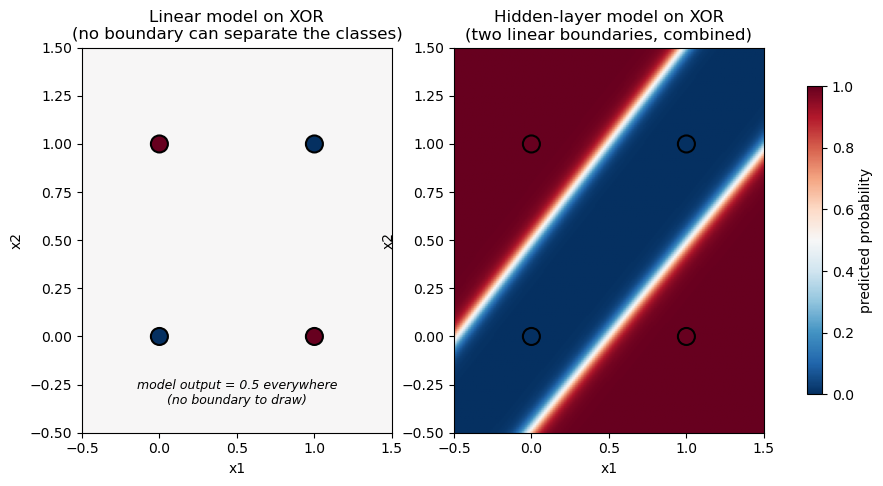

In [5]:
def plot_boundary(ax, predict_fn, title, annotate_flat=False):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        zz = predict_fn(grid).numpy().reshape(xx.shape)
    im = ax.imshow(zz, extent=(-0.5, 1.5, -0.5, 1.5), origin="lower", cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    ax.scatter(X[:, 0], X[:, 1], c=y_xor, cmap="RdBu_r", edgecolor="black", linewidth=1.5, s=150, vmin=0, vmax=1)
    if annotate_flat:
        ax.text(0.5, -0.35, "model output = 0.5 everywhere\n(no boundary to draw)", ha="center", fontsize=9, style="italic")
    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    return im

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
im0 = plot_boundary(axes[0], lambda g: torch.sigmoid(g @ w_xor + b_xor), "Linear model on XOR\n(no boundary can separate the classes)", annotate_flat=True)

# retrain the seed-0 hidden-layer model once more, keeping the raw parameters
# (not just its predictions) so we can reuse them in the plotting closure below
torch.manual_seed(0)
W1 = torch.randn(2, 2, requires_grad=True); b1 = torch.zeros(2, requires_grad=True)
W2 = torch.randn(2, requires_grad=True); b2 = torch.zeros(1, requires_grad=True)
params = [W1, b1, W2, b2]
for epoch in range(5000):
    h = torch.tanh(X @ W1 + b1)
    z = h @ W2 + b2
    pred = torch.sigmoid(z)
    loss = torch.nn.functional.binary_cross_entropy(pred, y_xor)
    loss.backward()
    with torch.no_grad():
        for p in params:
            p -= 0.5 * p.grad
            p.grad.zero_()

def mlp_predict(g):
    h = torch.tanh(g @ W1.detach() + b1.detach())
    return torch.sigmoid(h @ W2.detach() + b2.detach())

im1 = plot_boundary(axes[1], mlp_predict, "Hidden-layer model on XOR\n(two linear boundaries, combined)")
fig.colorbar(im1, ax=axes, shrink=0.8, label="predicted probability")
plt.show()

The left panel shows exactly why the linear model gave up: the two "true" corners `(0,1)` and `(1,0)` sit on opposite sides of the square from each other, so they can't be put on one side of any single straight line while the two "false" corners sit on the other. The right panel shows the hidden-layer model's solution: it combines two different linear boundaries (one per hidden unit) into a region that correctly isolates the two "true" corners — precisely the extra representational power a hidden layer buys you, and precisely what Day 10 uses to build a real secondary-structure predictor.